In [13]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras
import bayesflow as bf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

Variation 2 model

In [14]:
import numpy as np
from scipy.stats import invgauss

# fix one “typical” (ν,α₁,τ) and sweep α₂–scales to match p_double≈0.03
def theoretical_double_rate(nu, alpha1, tau, max_t, scale):
    """
    Draw alpha2 = alpha1 + Exp(scale),
    then compute P(FPT_loser ≤ max_t−tau)
    under the Inverse‐Gaussian(μ=alpha2/nu_min, λ=alpha2**2).
    """
    # use the *mean* extra barrier
    alpha2 = alpha1 + scale
    
    mu_late = alpha2 / np.min(nu)
    lam     = alpha2**2
    # P(T2 ≤ max_t−tau)
    return invgauss(mu_late, scale=lam).cdf(max_t - tau)

# choose your “typical” parameters
nu_typical    = np.array([0.5, 1.0])
alpha1_typical = 1.0
tau_typical    = 0.2
max_t_typical  = 3.0

# scan a few scales
scales = np.linspace(1.0, 50.0, 50)
rates  = [theoretical_double_rate(nu_typical,
                                  alpha1_typical,
                                  tau_typical,
                                  max_t_typical,
                                  s)
          for s in scales]

# find scale that gives ~3 % doubles
target = 0.03
idx    = np.argmin(np.abs(np.array(rates) - target))
best_scale = scales[idx]
print(f"⇒ Best exp-scale for extra barrier ≃ {best_scale:.1f}, "
      f"theoretical rate ≃ {rates[idx]:.3f}")


⇒ Best exp-scale for extra barrier ≃ 3.0, theoretical rate ≃ 0.019


In [15]:
import numpy as np
import bayesflow as bf

# ————— Context —————
def context():
    return {"n": 1000}



def prior(nu=None, alpha1=None, alpha2=None, tau=None):
    # two independent drifts
    if nu is None:
        nu = np.random.gamma(shape=5, scale=0.5, size=2)

    # first‐stage threshold
    if alpha1 is None:
        alpha1 = float(np.random.gamma(shape=5, scale=0.2))

    # second‐stage threshold = alpha1 + Exponential(best_scale)
    if alpha2 is None:
        # use the calibrated scale so that P(double)≈3%
        extra_barrier = np.random.exponential(scale=best_scale)
        alpha2 = float(alpha1 + extra_barrier)

    # non‐decision time
    if tau is None:
        tau = float(np.random.exponential(scale=0.15))

    return {"nu": nu, "alpha1": alpha1, "alpha2": alpha2, "tau": tau}


# def prior(nu=None, alpha1=None, alpha2=None, tau=None):
#     # Option 1: More conservative priors
#     if nu is None:
#         # Slower, more variable drift rates
#         nu = np.random.gamma(shape=2, scale=0.3, size=2)  # mean=0.6, more variable
    
#     if alpha1 is None:
#         # Higher first threshold
#         alpha1 = float(np.random.gamma(shape=4, scale=0.3))  # mean=1.2
    
#     if alpha2 is None:
#         # Keep the calibrated extra barrier
#         extra_barrier = np.random.exponential(scale=best_scale)
#         alpha2 = float(alpha1 + extra_barrier)
    
#     if tau is None:
#         # Larger non-decision time
#         tau = float(np.random.exponential(scale=0.25))  # mean=0.25
    
#     return {"nu": nu, "alpha1": alpha1, "alpha2": alpha2, "tau": tau}

# # Alternative Option 2: Even more conservative
# def prior_conservative(nu=None, alpha1=None, alpha2=None, tau=None):
#     if nu is None:
#         # Even slower drifts
#         nu = np.random.gamma(shape=1.5, scale=0.2, size=2)  # mean=0.3, very variable
    
#     if alpha1 is None:
#         # Much higher threshold
#         alpha1 = float(np.random.gamma(shape=6, scale=0.3))  # mean=1.8
    
#     if alpha2 is None:
#         extra_barrier = np.random.exponential(scale=best_scale)
#         alpha2 = float(alpha1 + extra_barrier)
    
#     if tau is None:
#         # Larger non-decision time with more variability
#         tau = float(np.random.gamma(shape=2, scale=0.15))  # mean=0.3, more variable
    
#     return {"nu": nu, "alpha1": alpha1, "alpha2": alpha2, "tau": tau}


# ————— first-passage helper —————
def first_passage_time(drift, threshold, max_t=3.0, dt=0.02):
    evidence = 0.0
    t = 0.0
    steps = int(max_t/dt)
    for _ in range(steps):
        t += dt
        evidence += drift * dt + np.random.normal(scale=np.sqrt(dt))
        if evidence >= threshold:
            return t
    return max_t

# ————— Single trial, now with 2nd threshold —————
def trial(nu, alpha1, alpha2, tau, max_t=3.0, dt=0.02):
    # 1) initial race to alpha1
    t0 = first_passage_time(nu[0], alpha1, max_t, dt)
    t1 = first_passage_time(nu[1], alpha1, max_t, dt)

    # 2) label winner & loser
    if t0 < t1:
        rt1, winner = t0 + tau, 0
        loser_drift = nu[1]
    else:
        rt1, winner = t1 + tau, 1
        loser_drift = nu[0]

    # 3) second-stage race of *loser* to alpha2
    t2 = first_passage_time(loser_drift, alpha2, max_t, dt)
    double_flag = 1.0 if t2 < max_t else 0.0
    time2       = (t2 + tau) if double_flag==1.0 else 0.0

    correct = 1.0 if winner==1 else 0.0
    return rt1, correct, double_flag, time2

# ————— Likelihood / simulator ————— #######from 0.2 to 0.1
def likelihood(n, nu, alpha1, alpha2, tau, max_t=3.0, dt=0.02):
    Time1      = np.zeros(n)
    Correct    = np.zeros(n)
    DoubleResp = np.zeros(n)
    Time2      = np.zeros(n)

    for i in range(n):
        rt1, corr, dr, t2 = trial(nu, alpha1, alpha2, tau, max_t, dt)
        Time1[i]      = rt1
        Correct[i]    = corr
        DoubleResp[i] = dr
        Time2[i]      = t2

    return {
      "Time1":      Time1,
      "Correct":    Correct,
      "DoubleResp": DoubleResp,
      "Time2":      Time2
    }

# ————— Build simulator —————
simulator = bf.make_simulator([context, prior, likelihood])


In [16]:
adapter = (
    bf.Adapter()
      .as_set(["Correct","Time1","DoubleResp","Time2"])
      .constrain(["nu","alpha1","alpha2","tau"], lower=0)
      .standardize(include="nu",    mean=0.7,  std=1.2)
      .standardize(include="alpha1",mean=0.5,  std=0.7)
      # α₂ now lives in [0,α₁], so mean≈0.25–0.5; choose something small
      .standardize(include="alpha2",mean=0.5,  std=0.5)
      .standardize(include="tau",   mean=-2.5, std=1.3)
      .concatenate(["nu","alpha1","alpha2","tau"],   into="inference_variables")
      .concatenate(["Correct","Time1","DoubleResp","Time2"], into="summary_variables")
)



workflow = bf.BasicWorkflow(
    simulator           = simulator,
    adapter             = adapter,
    # inference_network   = bf.networks.CouplingFlow(permutation="swap"),
    inference_network=bf.networks.CouplingFlow(
    n_flows=3,             # instead of the default 1
    subnet_kwargs=dict(widths=[128,128], dropout=0.1)
),
    summary_network     = bf.networks.DeepSet(base_distribution="normal"),
    inference_variables = ["nu","alpha1","alpha2","tau"],
    inference_conditions= ["n"],
    summary_variables   = ["Correct","Time1","DoubleResp","Time2"],

)


In [17]:

train_data      = simulator.sample(2500)
validation_data = simulator.sample(1000)

In [18]:
history = workflow.fit_offline(
    data=train_data,
    epochs=50,
    batch_size=120,
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - loss: 7.9728 - loss/inference_loss: 6.6773 - loss/summary_loss: 1.2954 - val_loss: 7.3414 - val_loss/inference_loss: 6.5532 - val_loss/summary_loss: 0.7881
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - loss: 6.4399 - loss/inference_loss: 5.8832 - loss/summary_loss: 0.5567 - val_loss: 6.5862 - val_loss/inference_loss: 5.7769 - val_loss/summary_loss: 0.8092
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - loss: 5.5798 - loss/inference_loss: 4.9824 - loss/summary_loss: 0.5975 - val_loss: 5.2913 - val_loss/inference_loss: 4.5090 - val_loss/summary_loss: 0.7823
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - loss: 4.6840 - loss/inference_loss: 4.1084 - loss/summary_loss: 0.5756 - val_loss: 4.2698 - val_loss/inference_loss: 3.4156 - val_loss/summary_loss: 0.8542
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 76s 4s/step - loss: 3.8218 - loss/inference_loss: 3.2764 - loss/summary_loss: 0.5454 - val_loss: 3.0067 - val_loss/inference_loss:

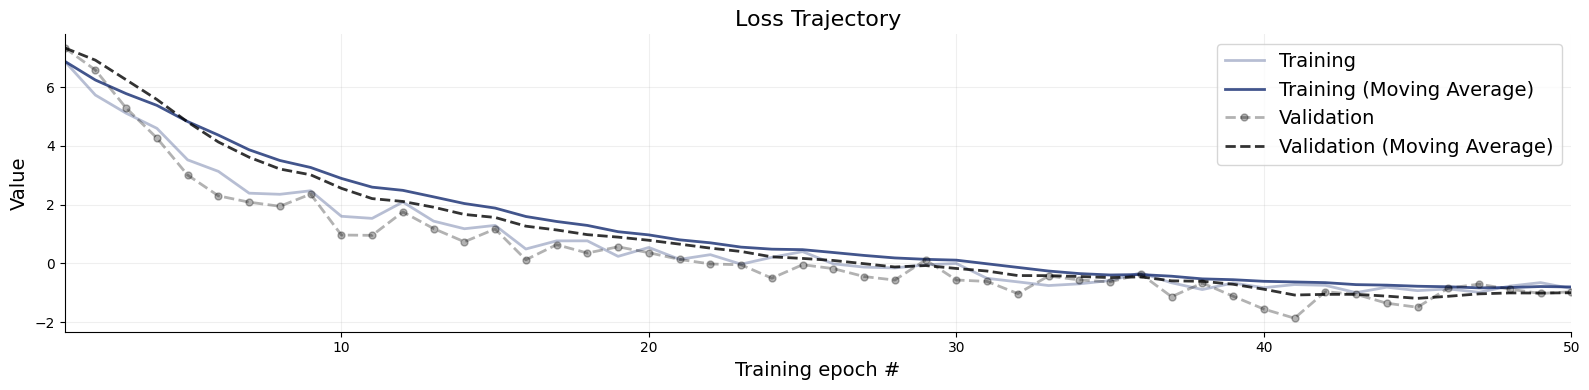

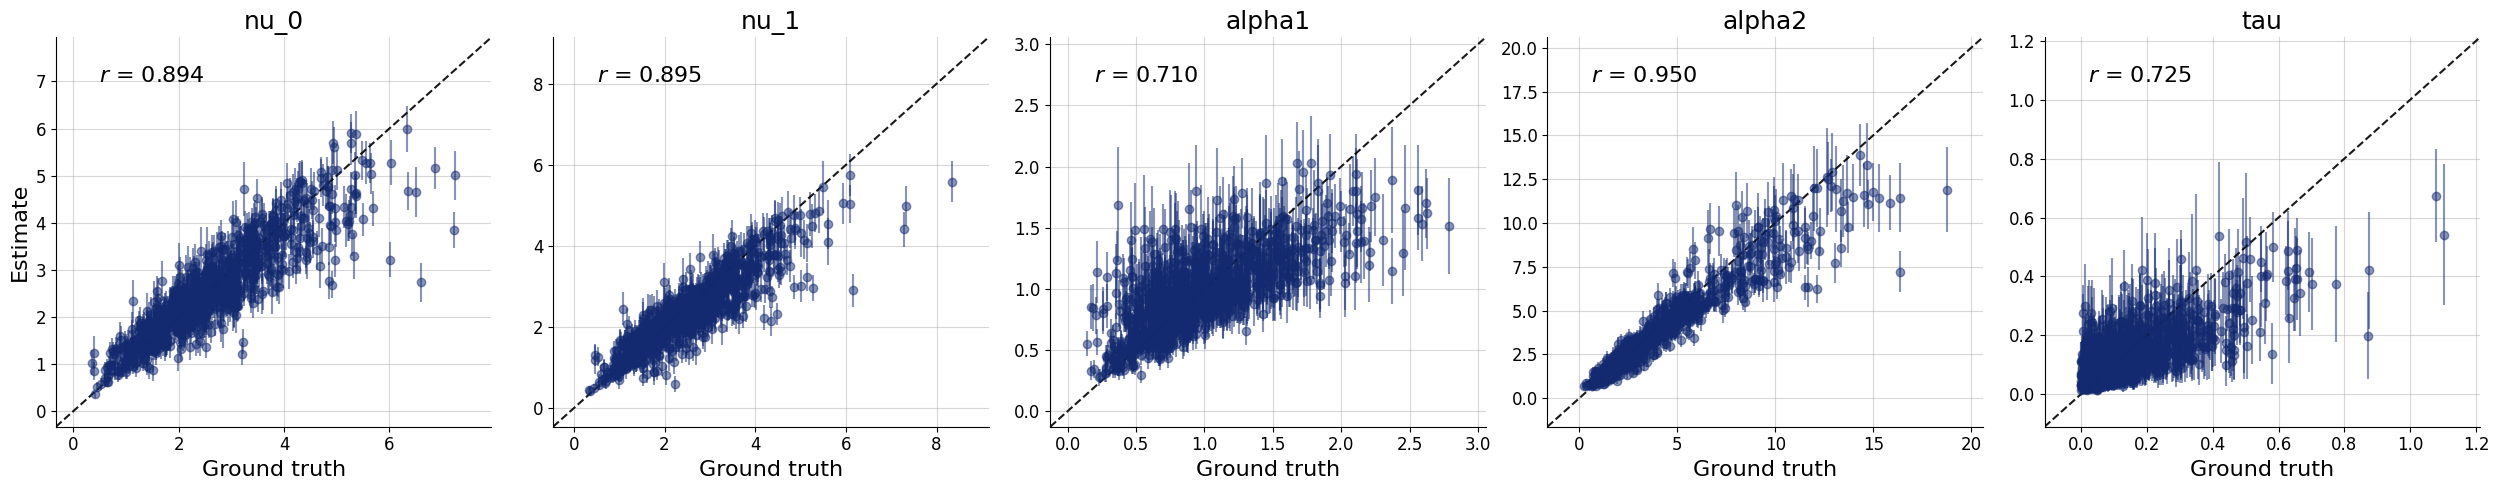

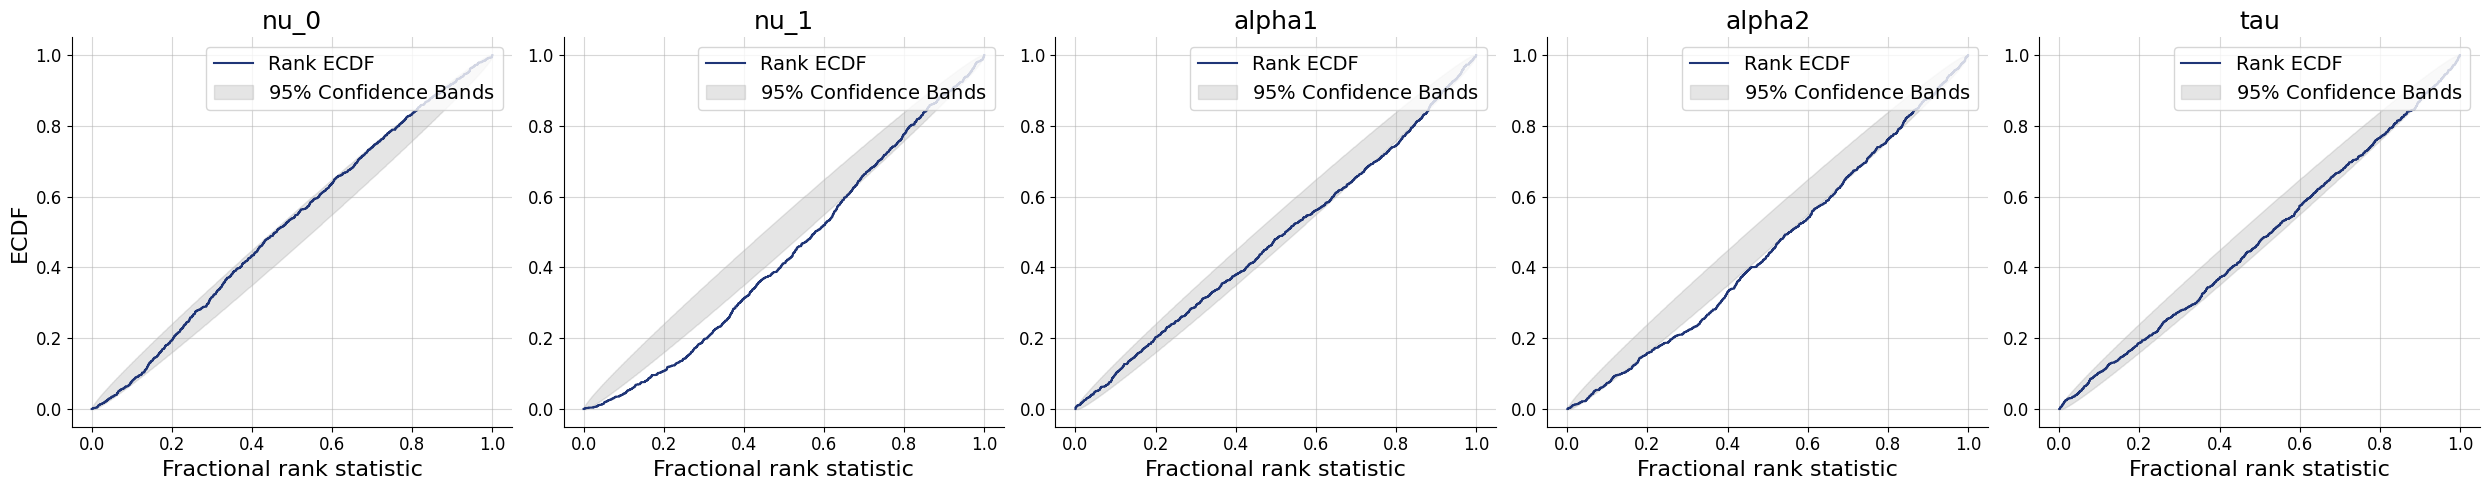

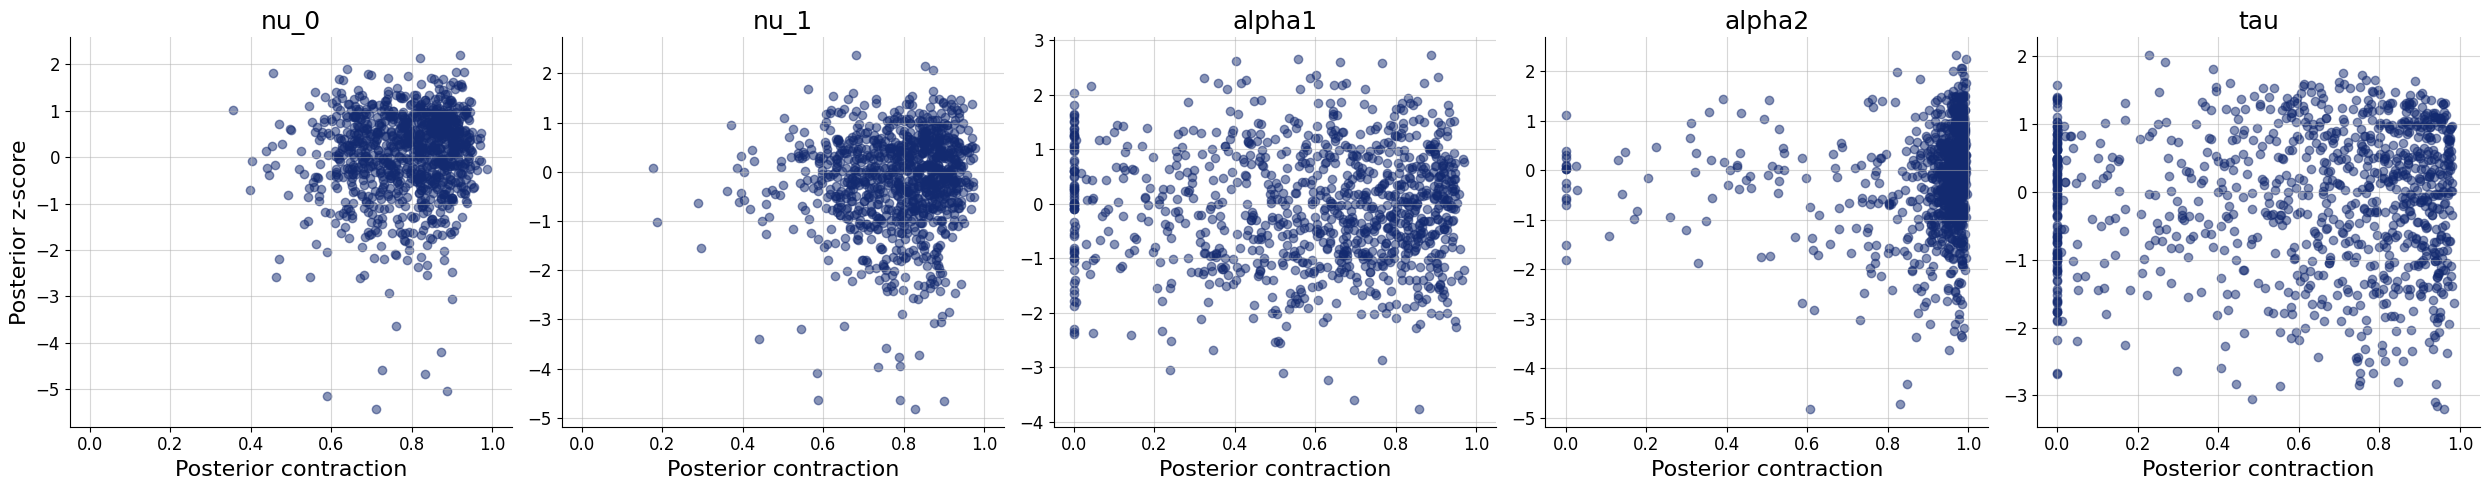

In [19]:
# 1. Draw 1 000 new “test” datasets (with known nu, alpha1, alpha2, tau)
test_data = simulator.sample(1000)

# 2. Compute & plot calibration/coverage/etc.
plots = workflow.plot_default_diagnostics(test_data=test_data)

In [20]:
metrics_v2 = workflow.compute_default_diagnostics(test_data=test_data)
print(metrics_v2)


                           nu_0      nu_1    alpha1    alpha2       tau
NRMSE                  0.106449  0.086806  0.164427  0.074987  0.131137
Posterior Contraction  0.804943  0.809650  0.666097  0.964160  0.717810
Calibration Error      0.022026  0.042447  0.030553  0.006658  0.010711


In [23]:
df_dr = pd.read_csv(
    "data/double_responses.csv",
    usecols=["list_id","Correct","Time1","DoubleResp","Time2"],
    dtype={
        "list_id":     "int32",
        "Correct":     "bool",
        "Time1":       "float32",
        "DoubleResp":  "bool",
        "Time2":       "float32"
    },
    low_memory=False
)

In [24]:
df_small_dr = (
    df_dr
    .groupby("list_id", group_keys=False)
    .sample(n=1000, replace=True, random_state=42)
    .reset_index(drop=True)
)

In [25]:
df_small_dr.head(10)

,list_id,Correct,Time1,DoubleResp,Time2
0,1,True,0.4038,False,NaN
1,1,True,0.4940,False,NaN
2,1,True,0.4668,False,NaN
3,1,False,0.3405,False,NaN
4,1,True,0.4158,False,NaN
5,1,True,0.3500,False,NaN
6,1,True,0.4629,False,NaN
7,1,False,0.5848,True,0.027
8,1,True,0.4109,False,NaN
9,1,True,0.3833,False,NaN


In [26]:
# Safely replace NaNs in Time2 with 0.0 and ensure float32 dtype
df_small_dr.loc[:, "Time2"] = (
    df_small_dr["Time2"]
    .fillna(0.0)
    .astype(np.float32)
)

# Verify no missing values remain
print("Remaining NaNs in Time2:", df_small_dr["Time2"].isna().sum())


Remaining NaNs in Time2: 0


In [27]:
df_small_dr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   list_id     4000 non-null   int32  
 1   Correct     4000 non-null   bool   
 2   Time1       4000 non-null   float32
 3   DoubleResp  4000 non-null   bool   
 4   Time2       4000 non-null   float32
dtypes: bool(2), float32(2), int32(1)
memory usage: 54.8 KB


In [28]:
max_n   = 1000
grouped = df_small_dr.groupby("list_id", sort=False)
n_lists = len(grouped)

conditions = {
    # summary_variables: each is shape (n_lists, max_n, 1), dtype float32
    "Correct": np.stack(
        [g["Correct"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),
    "Time1": np.stack(
        [g["Time1"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),
    "DoubleResp": np.stack(
        [g["DoubleResp"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),
    "Time2": np.stack(
        [g["Time2"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),

    # inference_conditions: number of trials per list (shape (n_lists,)), dtype int32
    "n": np.array([g.shape[0] for _, g in grouped], dtype=np.int32)
}

print({k: v.shape for k, v in conditions.items()})
# => {
#   'Correct':    (n_lists, 1000, 1),
#   'Time1':      (n_lists, 1000, 1),
#   'DoubleResp': (n_lists, 1000, 1),
#   'Time2':      (n_lists, 1000, 1),
#   'n':          (n_lists,)
# }


{'Correct': (4, 1000, 1), 'Time1': (4, 1000, 1), 'DoubleResp': (4, 1000, 1), 'Time2': (4, 1000, 1), 'n': (4,)}


In [29]:
# Draw 1 000 posterior samples for your real‐data conditions using the trained Variation 2 workflow
posterior_real = workflow.sample(
    num_samples = 1000,
    conditions  = conditions
)


In [30]:
for name, arr in posterior_real.items():
    total = arr.size
    n_nan = np.isnan(arr).sum()
    pct   = 100 * n_nan / total
    print(f"{name:10s} → {n_nan}/{total} NaNs ({pct:.1f}%)")

nu         → 0/8000 NaNs (0.0%)
alpha1     → 0/4000 NaNs (0.0%)
alpha2     → 0/4000 NaNs (0.0%)
tau        → 0/4000 NaNs (0.0%)


In [31]:
# 1) Get an ordered list of your subject IDs
group_keys     = list(grouped.groups.keys())

# 2) Pick the “first” one (or any by index)
first_list_id  = group_keys[0]
print("First list_id:", first_list_id)

# 3) Grab its data
data_first = grouped.get_group(first_list_id).reset_index(drop=True)
print("Data for first participant shape:", data_first.shape)

# 4) Find its index in that list
idx = group_keys.index(first_list_id)

# 5) Slice out *all* 1 000 posterior draws for that subject
#    posterior_real has keys: "nu", "alpha1", "alpha2", "tau"
posterior_first = {
    "nu":     posterior_real["nu"][    idx, :, :],   # → (1000, 2)
    "alpha1": posterior_real["alpha1"][idx, :, 0],   # → (1000,)
    "alpha2": posterior_real["alpha2"][idx, :, 0],   # → (1000,)
    "tau":    posterior_real["tau"][   idx, :, 0]    # → (1000,)
}

print("Posterior for first participant:")
for name, arr in posterior_first.items():
    print(f"  {name:7s} → {arr.shape}")



First list_id: 1
Data for first participant shape: (1000, 5)
Posterior for first participant:
  nu      → (1000, 2)
  alpha1  → (1000,)
  alpha2  → (1000,)
  tau     → (1000,)


In [ ]:
# 1) Get an ordered list of your subject IDs
group_keys     = list(grouped.groups.keys())

# 2) Pick the “first” one (or any by index)
first_list_id  = group_keys[0]
print("First list_id:", first_list_id)

# 3) Grab its data
data_first = grouped.get_group(first_list_id).reset_index(drop=True)
print("Data for first participant shape:", data_first.shape)

# 4) Find its index in that list
idx = group_keys.index(first_list_id)

# 5) Slice out *all* 1 000 posterior draws for that subject
#    posterior_real has keys: "nu", "alpha1", "alpha2", "tau"
posterior_first = {
    "nu":     posterior_real["nu"][    idx, :, :],   # → (1000, 2)
    "alpha1": posterior_real["alpha1"][idx, :, 0],   # → (1000,)
    "alpha2": posterior_real["alpha2"][idx, :, 0],   # → (1000,)
    "tau":    posterior_real["tau"][   idx, :, 0]    # → (1000,)
}

print("Posterior for first participant:")
for name, arr in posterior_first.items():
    print(f"  {name:7s} → {arr.shape}")



Processing subject: 1
Data shape: (1000, 5)
Posterior shapes:
nu      → (1000, 2)
alpha1  → (1000,)
alpha2  → (1000,)
tau     → (1000,)

Processing subject: 2
Data shape: (1000, 5)
Posterior shapes:
nu      → (1000, 2)
alpha1  → (1000,)
alpha2  → (1000,)
tau     → (1000,)

Processing subject: 3
Data shape: (1000, 5)
Posterior shapes:
nu      → (1000, 2)
alpha1  → (1000,)
alpha2  → (1000,)
tau     → (1000,)

Processing subject: 4
Data shape: (1000, 5)
Posterior shapes:
nu      → (1000, 2)
alpha1  → (1000,)
alpha2  → (1000,)
tau     → (1000,)


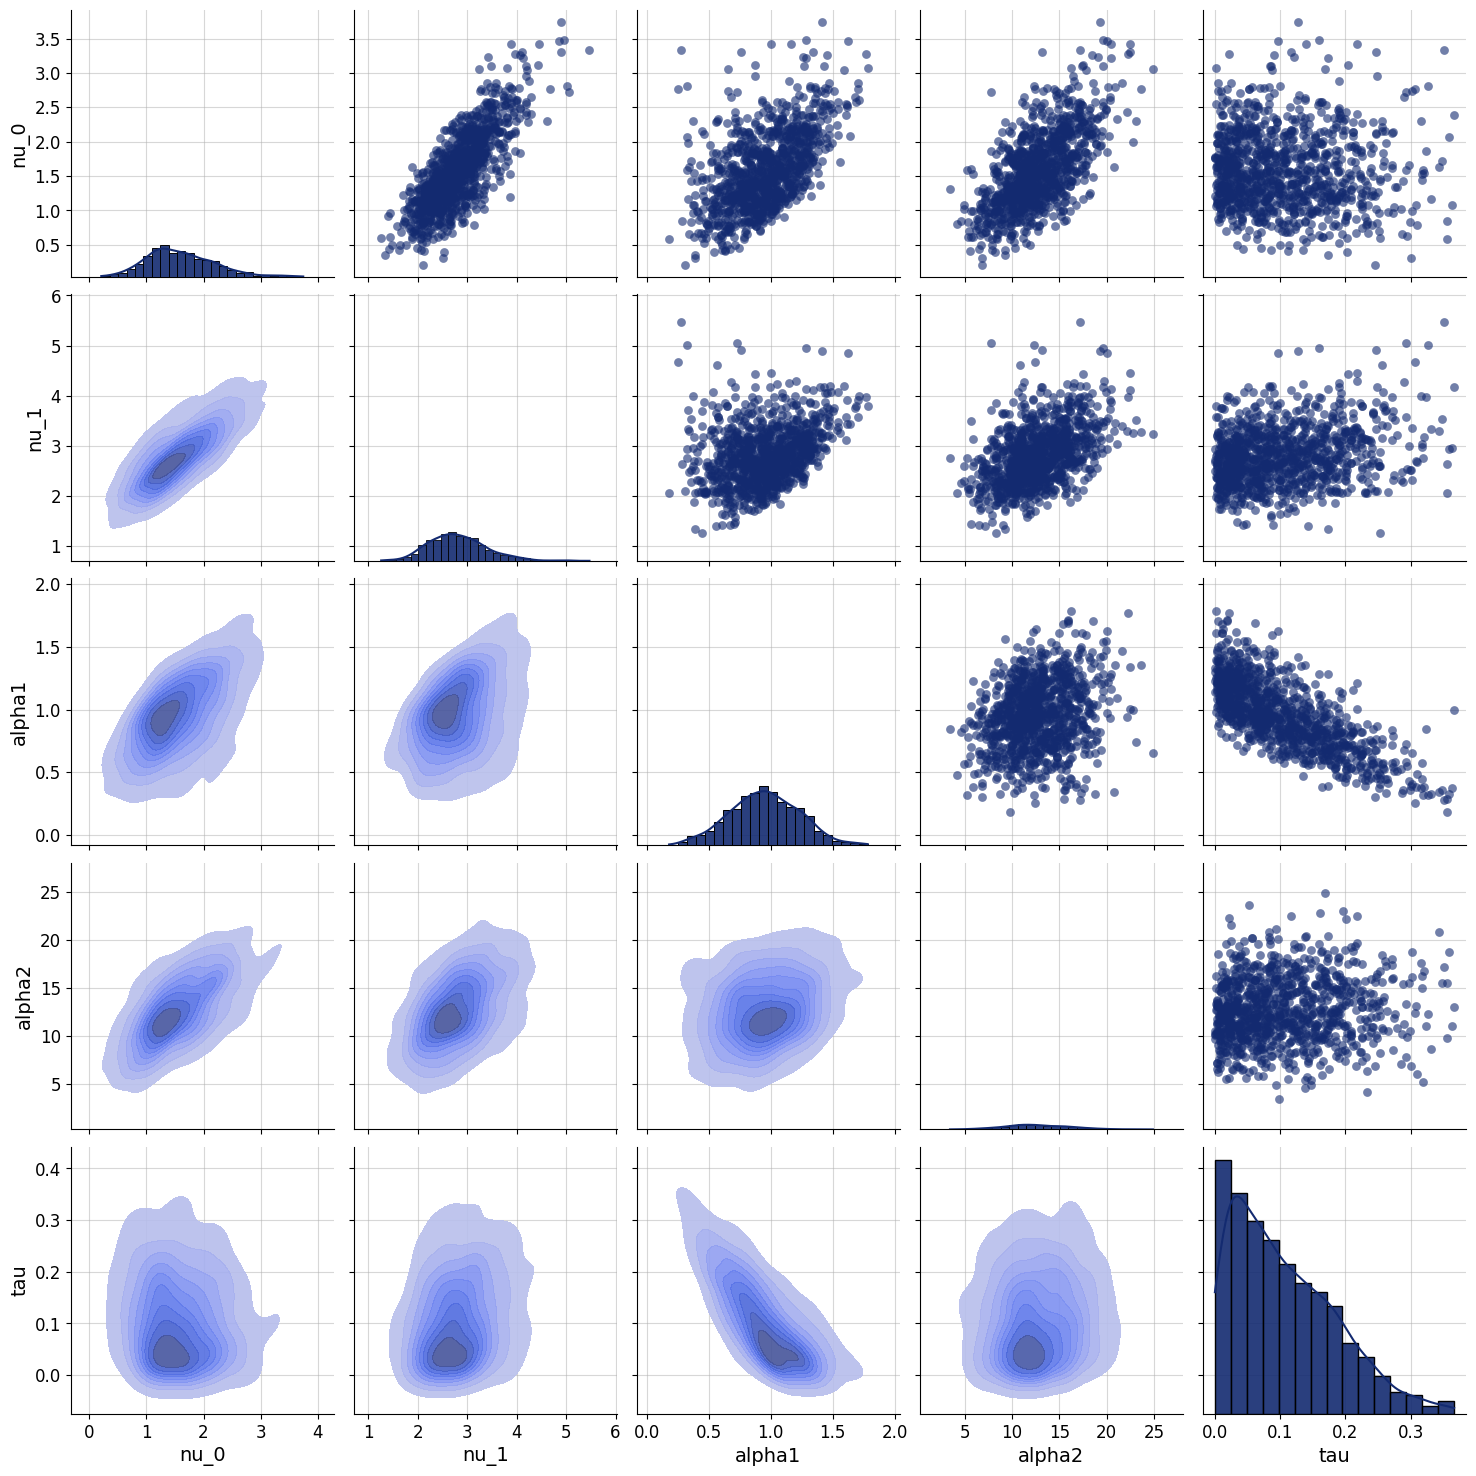

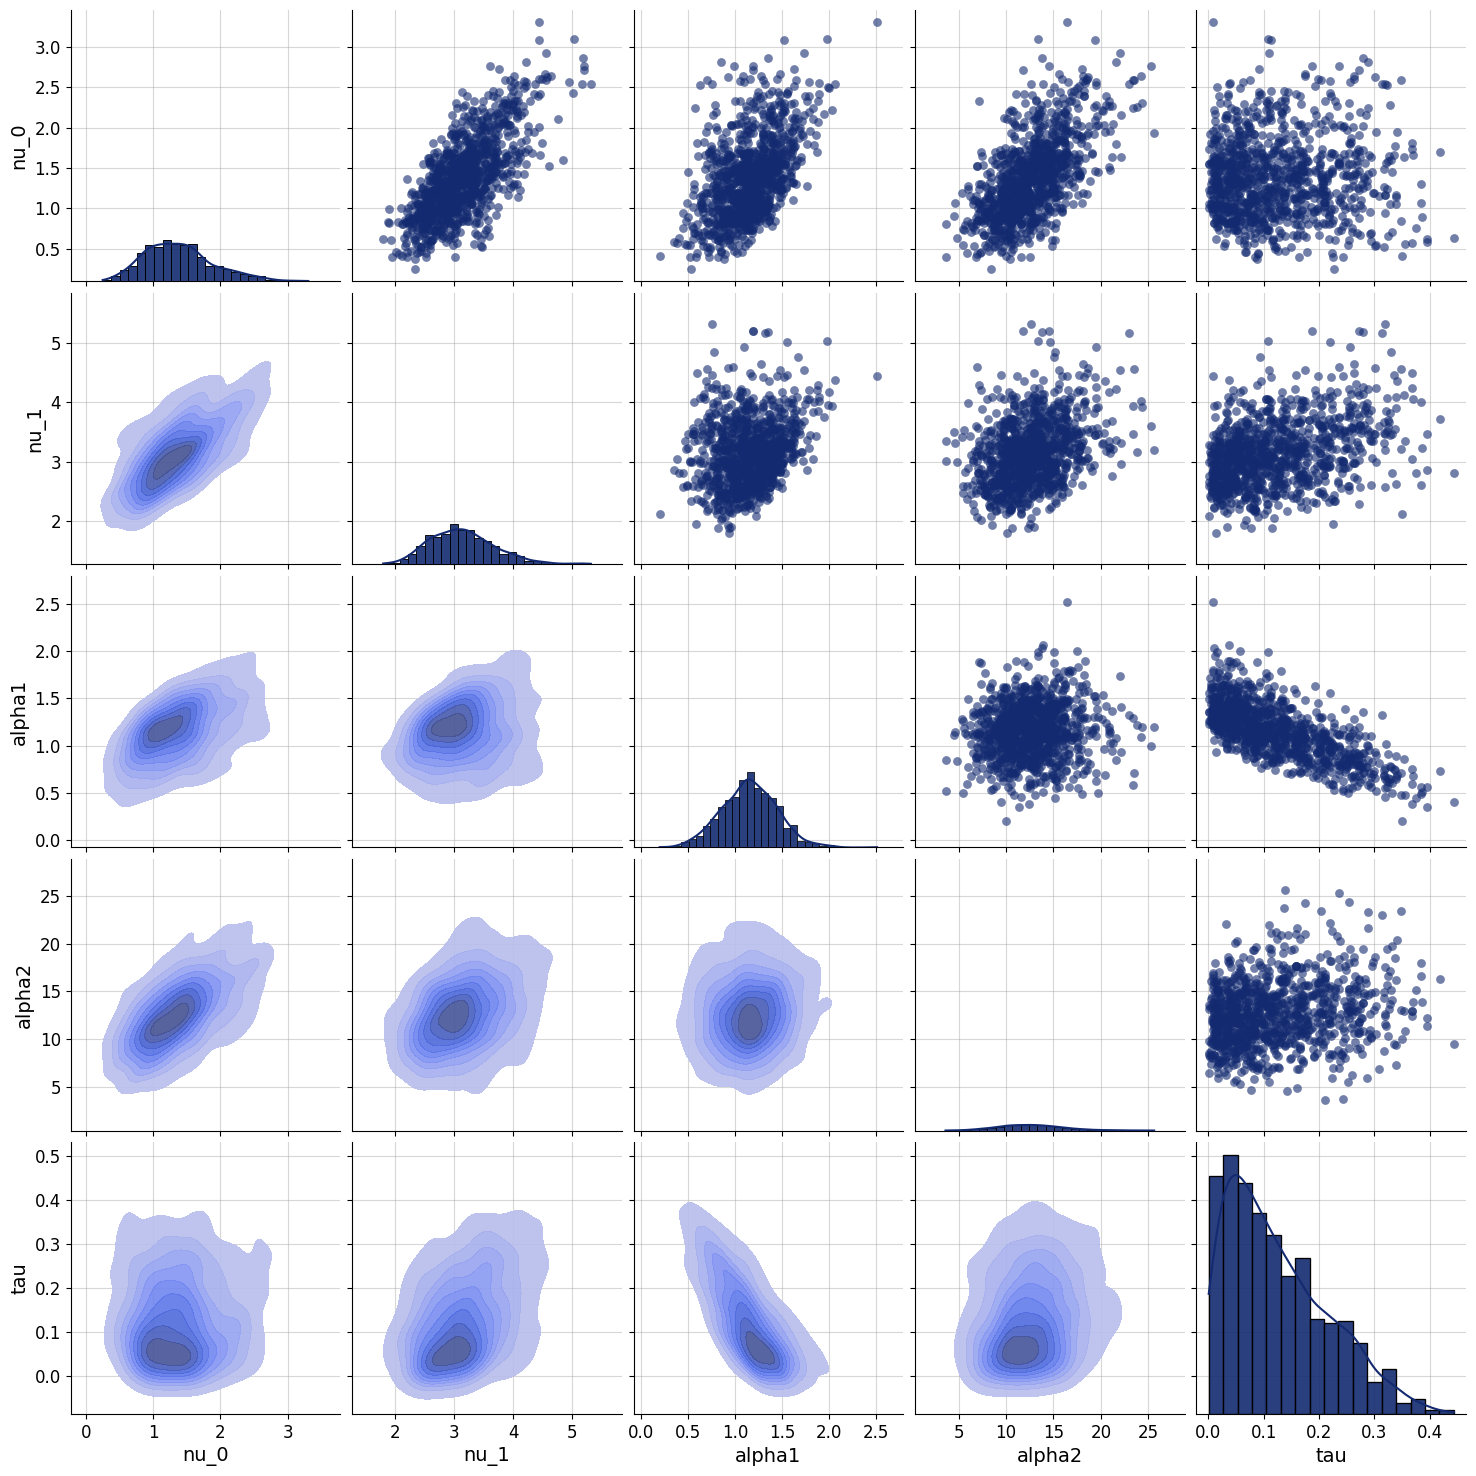

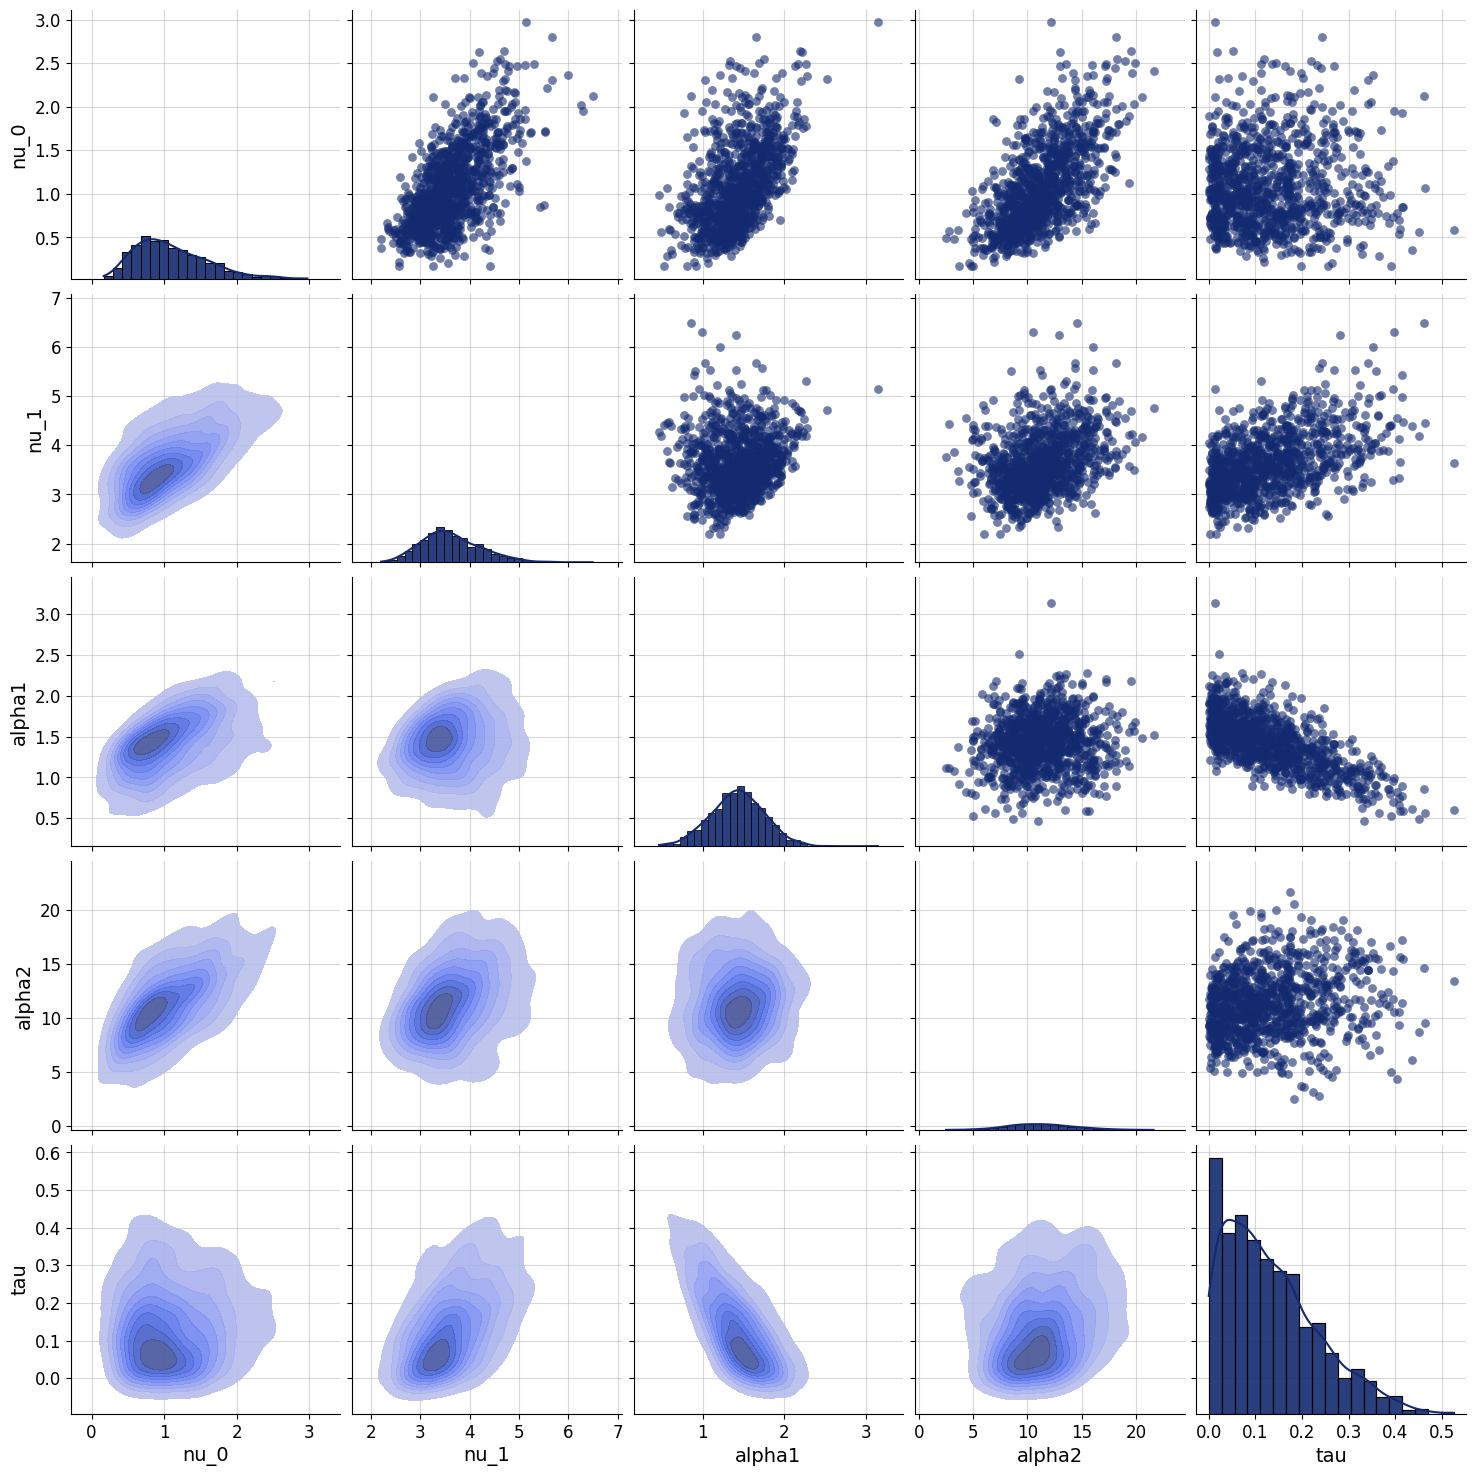

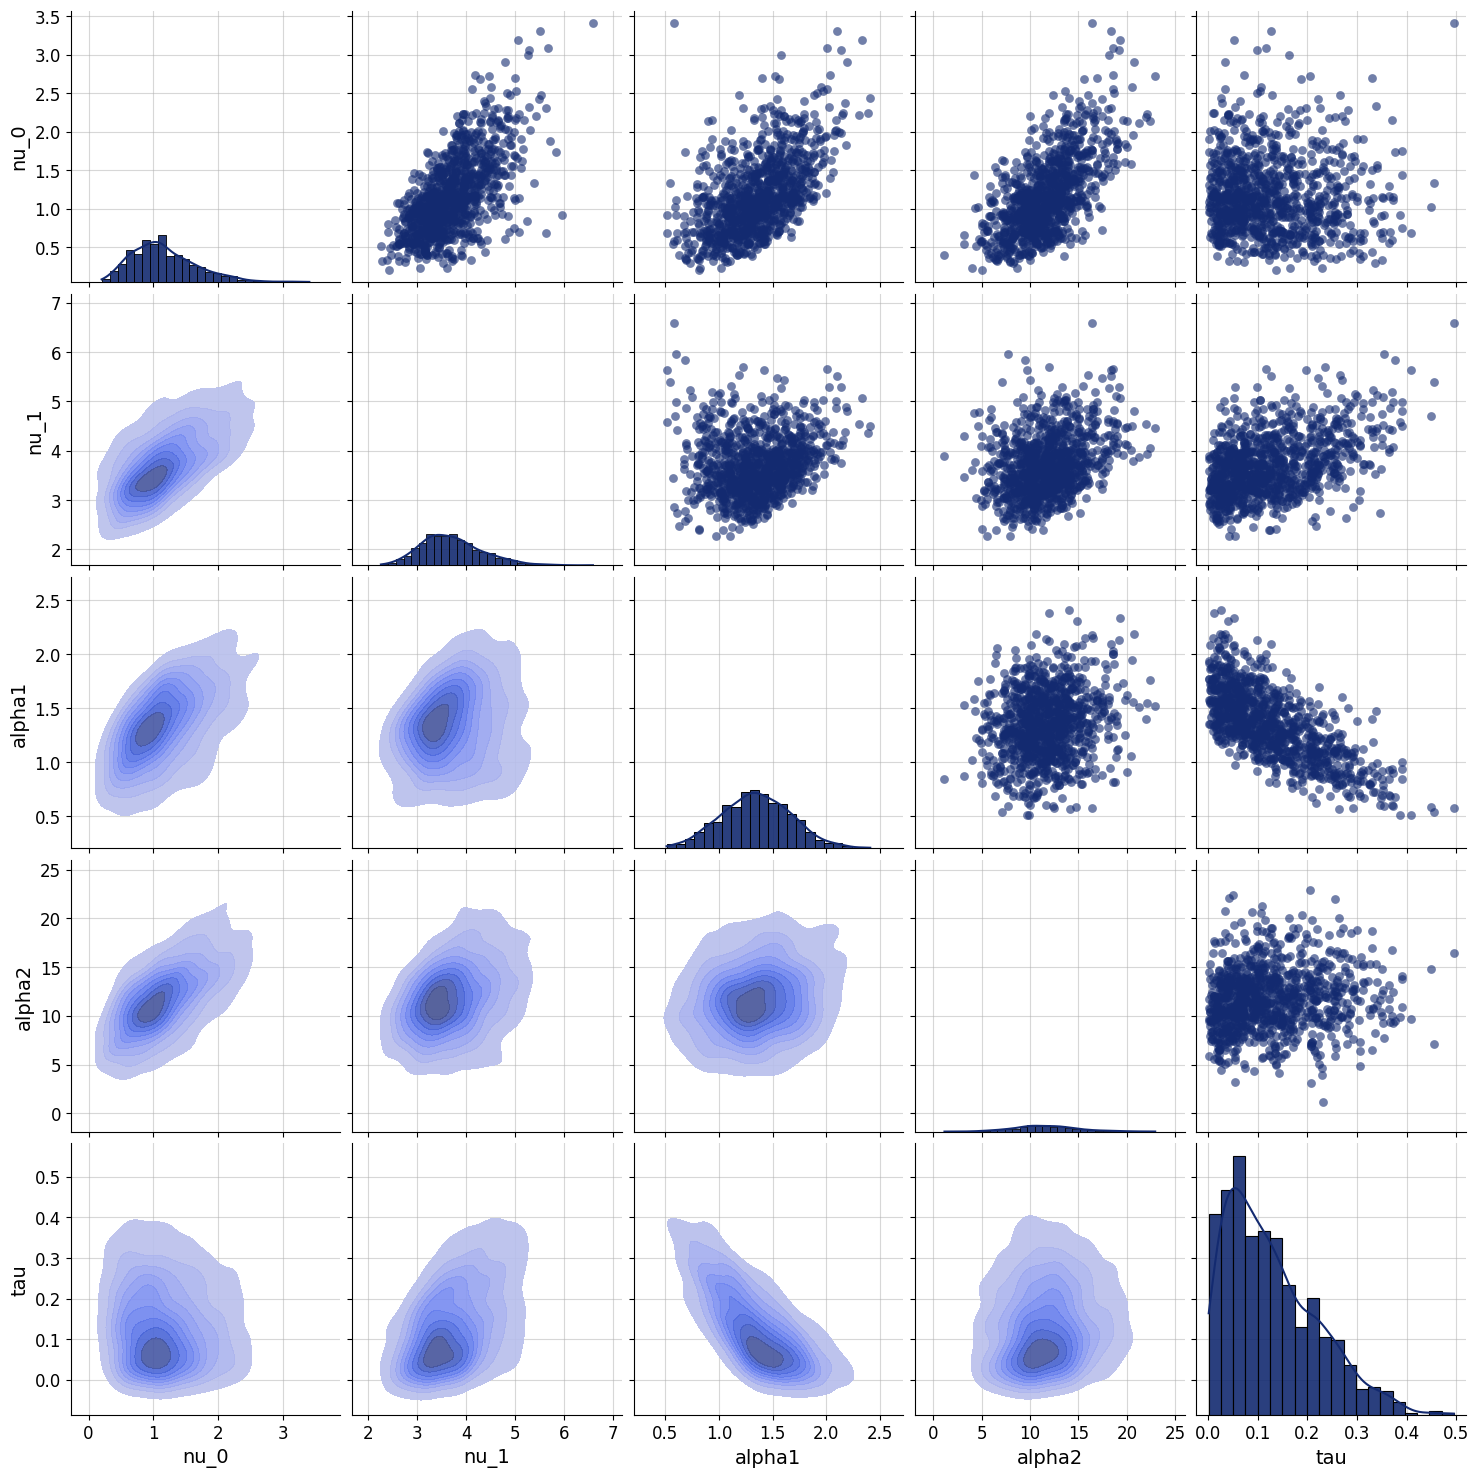

In [49]:
# Get an ordered list of your subject IDs
group_keys = list(grouped.groups.keys())

# Loop through all subjects
for subject_id in group_keys:
    print("\nProcessing subject:", subject_id)

    # Grab subject's data
    data_subject = grouped.get_group(subject_id).reset_index(drop=True)
    print("Data shape:", data_subject.shape)

    # Find index of subject
    idx = group_keys.index(subject_id)

    # Slice out all 1000 posterior draws for that subject
    posterior_subject = {
        "nu":     posterior_real["nu"][idx, :, :],      # (1000, 2)
        "alpha1": posterior_real["alpha1"][idx, :, 0],  # (1000,)
        "alpha2": posterior_real["alpha2"][idx, :, 0],  # (1000,)
        "tau":    posterior_real["tau"][idx, :, 0]      # (1000,)
    }

    # Print posterior shapes
    print("Posterior shapes:")
    for name, arr in posterior_subject.items():
        print(f"{name:7s} → {arr.shape}")

    # Optional: Uncomment to plot (could be slow for many subjects)
    bf.diagnostics.pairs_posterior(estimates=posterior_subject)


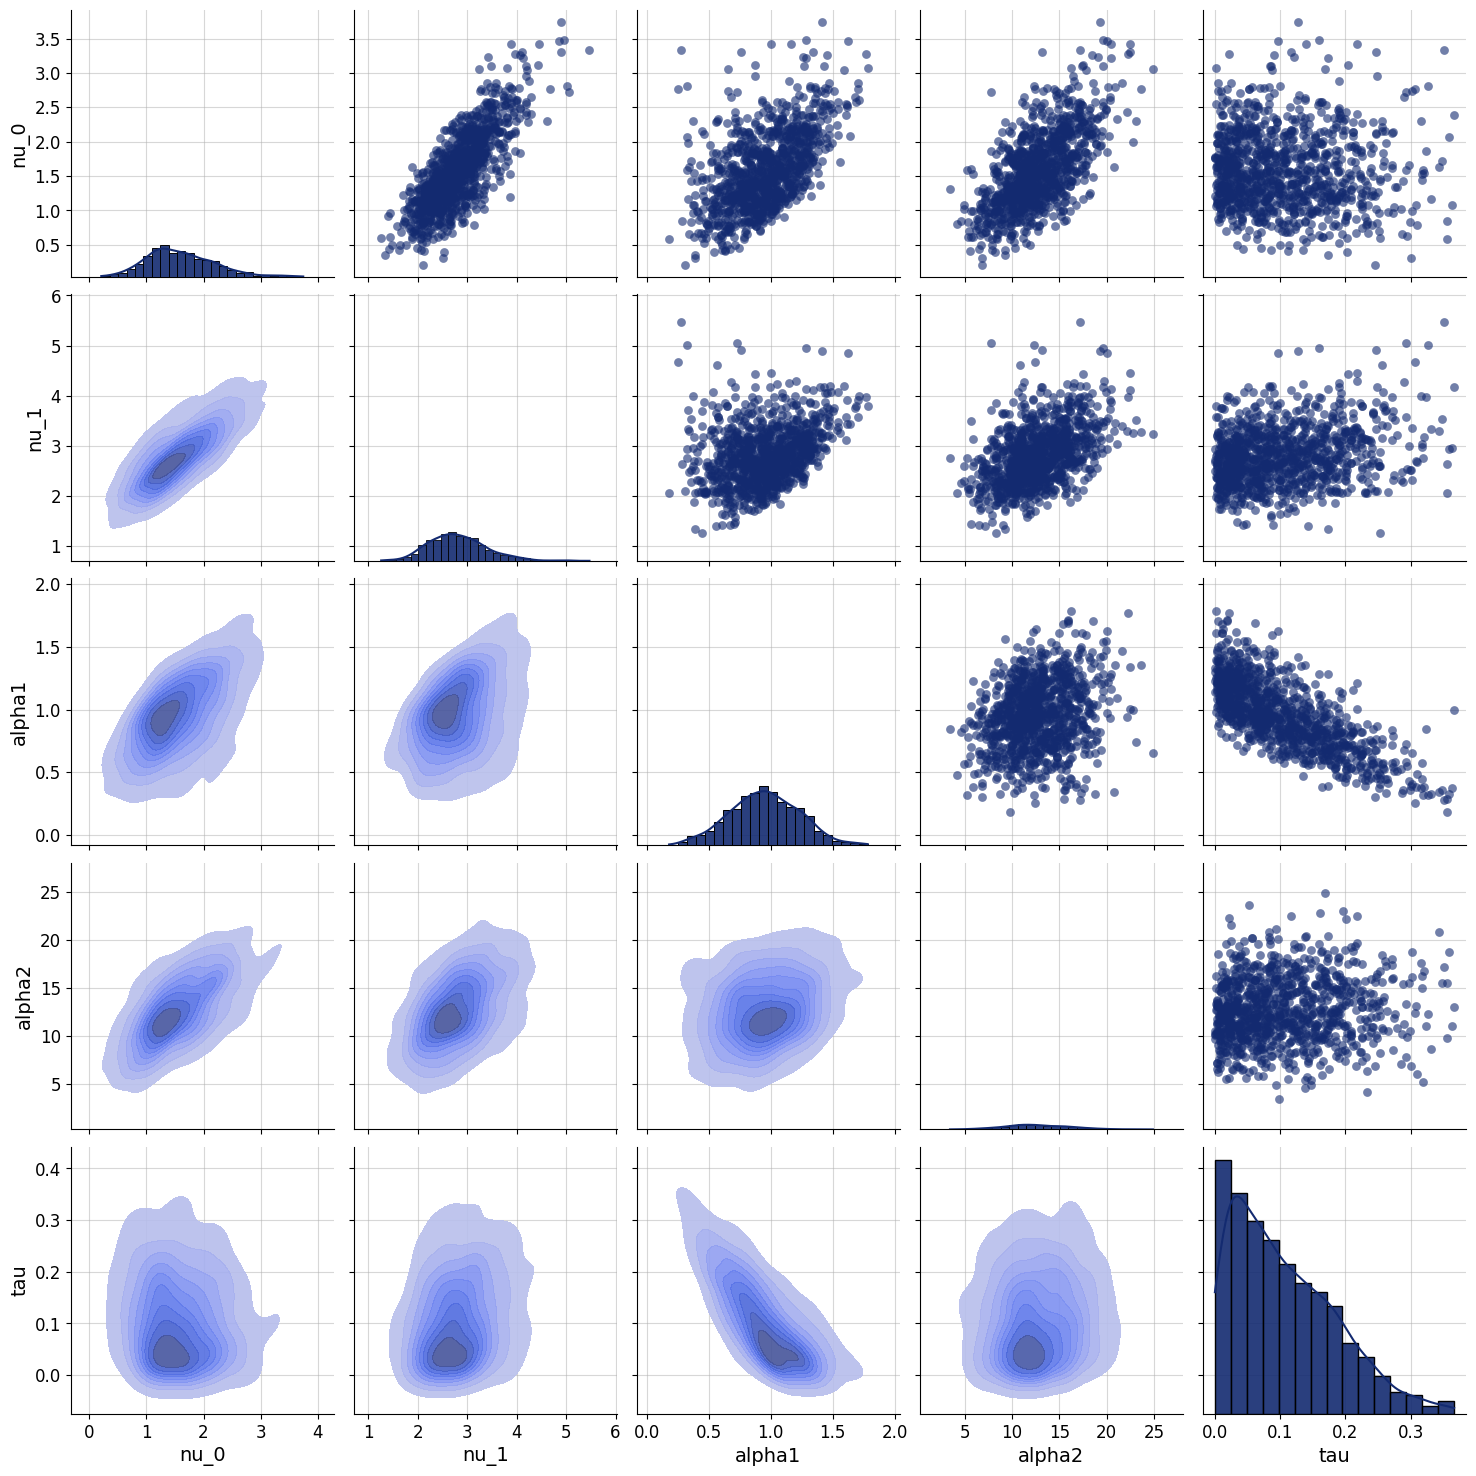

In [32]:
f=bf.diagnostics.pairs_posterior(estimates=posterior_first)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ——— ECDF on a fixed grid ——————————————————————
def ecdf_grid(Time1, Correct, t_grid):
    """
    Compute weighted ECDFs for incorrect (c=0) and correct (c=1) trials.
    Returns an array of shape (2, len(t_grid)) where each row is
      P(Time1 ≤ t and class==c) over the full sample size.
    """
    corr = Correct.astype(bool)
    N    = len(Time1)
    ecdf = np.zeros((2, len(t_grid)))

    for c in (0, 1):
        mask = corr if c == 1 else ~corr
        for i, t in enumerate(t_grid):
            ecdf[c, i] = np.sum((Time1 <= t) & mask) / N

    return ecdf

# ——— Posterior‐predictive ECDF plot for one subject ——————————————————————
def plot_group_pp_ecdf(grp_df,
                       workflow,
                       likelihood_fn,
                       n_posterior=500,
                       t_max=3.0,
                       dt=0.02):
    """
    grp_df: DataFrame for one subject, must contain
      "Time1", "Correct", "DoubleResp", "Time2"
    workflow: trained BasicWorkflow (Variation 2)
    likelihood_fn: your two‐threshold likelihood, e.g. likelihood_v2
    """
    n_trials = grp_df.shape[0]

    # A) Build the single‐subject “conditions” dict
    cond = {
        "Time1":      grp_df["Time1"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "Correct":    grp_df["Correct"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "DoubleResp": grp_df["DoubleResp"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "Time2":      grp_df["Time2"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "n":          np.array([n_trials], dtype=np.int32)
    }

    # B) Draw posterior samples
    post = workflow.sample(conditions=cond, num_samples=n_posterior)
    nu_draws     = post["nu"].squeeze()      # (n_post, 2)
    alpha1_draws = post["alpha1"].squeeze()  # (n_post,)
    alpha2_draws = post["alpha2"].squeeze()  # (n_post,)
    tau_draws    = post["tau"].squeeze()     # (n_post,)

    # C) Empirical ECDF on a grid
    t_grid = np.linspace(0, t_max, 101)
    e_ecdf = ecdf_grid(
        Time1   = grp_df["Time1"].values,
        Correct = grp_df["Correct"].values,
        t_grid  = t_grid
    )

    # D) Posterior‐predictive ECDFs
    pp_ecdfs = np.zeros((n_posterior, 2, len(t_grid)))
    for i in range(n_posterior):
        sim = likelihood_fn(
            n       = n_trials,
            nu      = nu_draws[i],
            alpha1  = float(alpha1_draws[i]),
            alpha2  = float(alpha2_draws[i]),
            tau     = float(tau_draws[i]),
            max_t   = t_max,
            dt      = dt
        )
        pp_ecdfs[i] = ecdf_grid(
            Time1   = sim["Time1"],
            Correct = sim["Correct"],
            t_grid  = t_grid
        )

    # E) Compute 25/50/75% quantiles
    q_low, q_med, q_high = np.quantile(pp_ecdfs,
                                       [0.25, 0.5, 0.75],
                                       axis=0)

    # F) Plot
    fig, ax = plt.subplots(figsize=(5,4))
    for c, label, col in zip([0,1], ["Incorrect","Correct"], ["C0","C1"]):
        ax.plot(t_grid,     e_ecdf[c],
                color=col, lw=2, label=f"{label} (emp)")
        ax.plot(t_grid,     q_med[c],
                color=col, lw=1, ls="--",
                label=f"{label} (pred median)")
        ax.fill_between(
            t_grid,
            q_low[c],
            q_high[c],
            color=col, alpha=0.3,
            label=f"{label} (50% pred)"
        )

    ax.set_xlabel("First‐response RT (s)")
    ax.set_ylabel("Weighted ECDF")
    ax.legend(fontsize="small", ncol=2)
    ax.set_title(f"Subject {grp_df['list_id'].iloc[0]} – Posterior‐Predictive ECDF")
    plt.tight_layout()
    return fig


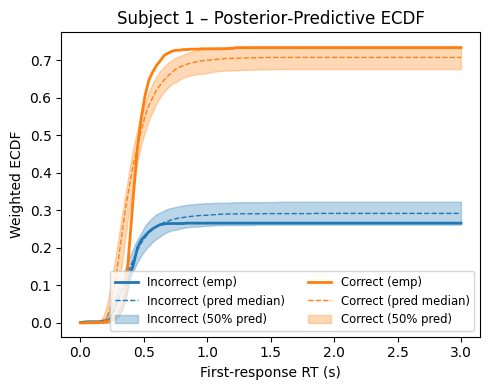

In [34]:
# for example, to plot for your first subject:
first_id = group_keys[0]
grp_df   = grouped.get_group(first_id).reset_index(drop=True)

fig = plot_group_pp_ecdf(
    grp_df,
    workflow,       # your trained Variation 2 workflow
    likelihood,     # the two‐threshold simulator fn
    n_posterior=500,   # fewer draws if you want speed
    t_max=3.0,
    dt=0.02
)
plt.show()


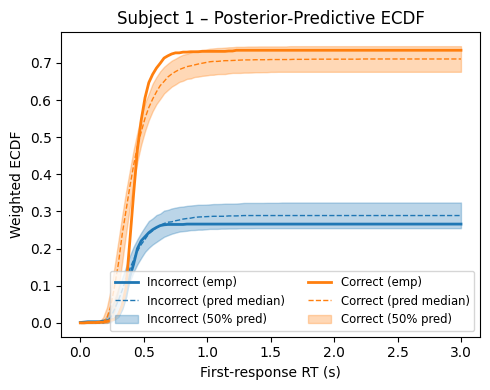

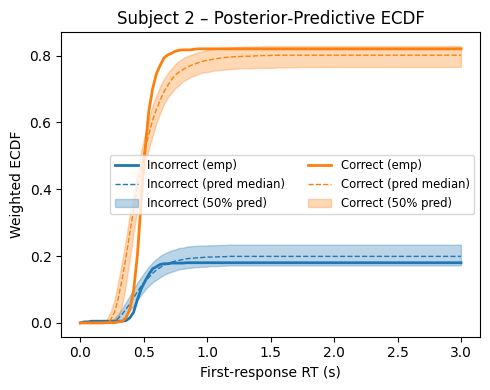

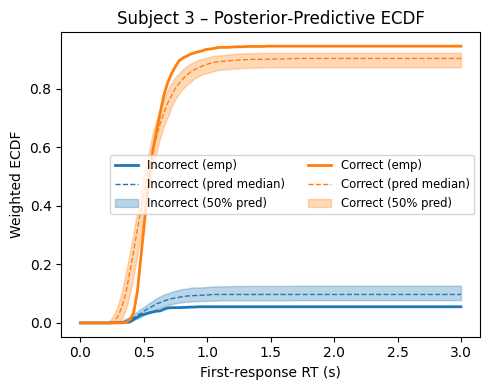

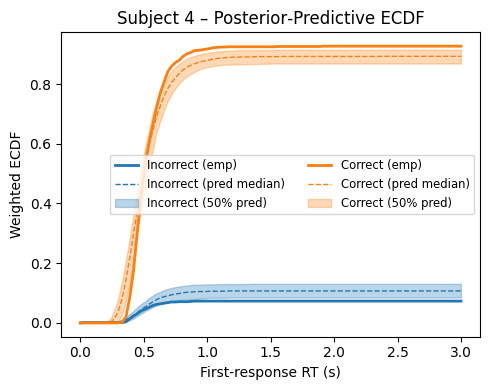

In [35]:
# Loop over all subjects and plot each ECDF
for list_id in group_keys:
    grp_df = grouped.get_group(list_id).reset_index(drop=True)
    fig = plot_group_pp_ecdf(
        grp_df,
        workflow,    # your trained Variation 2 workflow
        likelihood,  # your two-threshold likelihood function
        n_posterior=500,
        t_max=3.0,
        dt=0.02
    )
    plt.show()  # display each figure before moving on



DOUBLE RESPONSE ANALYSIS


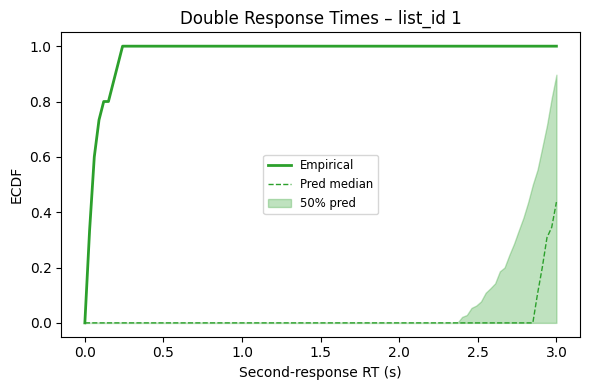

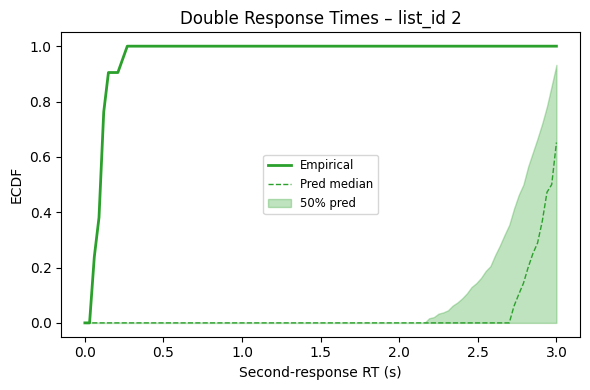

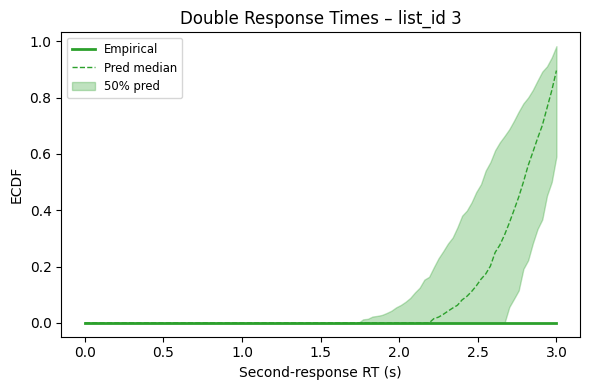

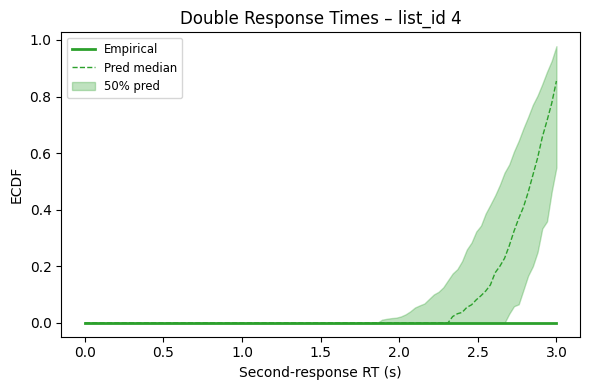

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def ecdf_grid_double_response(Time2, DoubleResp, t_grid):
    """
    ECDF of second‐response times only over trials where DoubleResp==True.
    Returns P(Time2 <= t | DoubleResp=True) on the t_grid.
    """
    mask     = DoubleResp.astype(bool)
    n_double = mask.sum()
    if n_double == 0:
        return np.zeros_like(t_grid)
    ecdf = np.zeros(len(t_grid))
    for i, t in enumerate(t_grid):
        ecdf[i] = np.sum(Time2[mask] <= t) / n_double
    return ecdf

print("\n" + "="*50)
print("DOUBLE RESPONSE ANALYSIS")
print("="*50)

# iterate over each subject
for list_id, grp_df in df_small_dr.groupby("list_id", sort=False):
    n_trials = grp_df.shape[0]

    # build conditions dict with correct shapes/dtypes
    cond = {
        "Time1":      grp_df["Time1"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "Correct":    grp_df["Correct"].astype(bool).to_numpy().reshape(1, -1, 1).astype(np.float32),
        "DoubleResp": grp_df["DoubleResp"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "Time2":      grp_df["Time2"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "n":          np.array([n_trials], dtype=np.int32)
    }

    # draw posterior samples under Variation 2 workflow
    post = workflow.sample(conditions=cond, num_samples=500)
    nu_draws     = post["nu"].squeeze()      # (500, 2)
    alpha1_draws = post["alpha1"].squeeze()  # (500,)
    alpha2_draws = post["alpha2"].squeeze()  # (500,)
    tau_draws    = post["tau"].squeeze()     # (500,)

    # empirical ECDF for Time2
    t_grid_double = np.linspace(0, 3.0, 101)
    e_ecdf_double = ecdf_grid_double_response(
        Time2      = grp_df["Time2"].values,
        DoubleResp = grp_df["DoubleResp"].values,
        t_grid     = t_grid_double
    )

    # posterior‐predictive ECDFs for Time2
    pp_ecdfs_double = np.zeros((500, len(t_grid_double)))
    for i in range(500):
        sim = likelihood(
            n       = n_trials,
            nu      = nu_draws[i],
            alpha1  = float(alpha1_draws[i]),
            alpha2  = float(alpha2_draws[i]),
            tau     = float(tau_draws[i])
        )
        pp_ecdfs_double[i] = ecdf_grid_double_response(
            Time2      = sim["Time2"],
            DoubleResp = sim["DoubleResp"],
            t_grid     = t_grid_double
        )

    # compute 25/50/75% quantiles
    q_low, q_med, q_high = np.quantile(pp_ecdfs_double,
                                       [0.25, 0.5, 0.75],
                                       axis=0)

    # plot
    plt.figure(figsize=(6, 4))
    plt.plot(t_grid_double, e_ecdf_double,
             color="C2", lw=2, label="Empirical")
    plt.plot(t_grid_double, q_med,
             color="C2", lw=1, ls="--", label="Pred median")
    plt.fill_between(t_grid_double, q_low, q_high,
                     color="C2", alpha=0.3, label="50% pred")
    plt.xlabel("Second‐response RT (s)")
    plt.ylabel("ECDF")
    plt.title(f"Double Response Times – list_id {list_id}")
    plt.legend(fontsize="small")
    plt.tight_layout()
    plt.show()



In [37]:
import bayesflow as bf

# ─── A) Simulate test data with known parameters ─────────────────────────
# Draw 1 000 “test” datasets from your two-threshold simulator
test_sims_v2 = simulator.sample(1000)


C:\Users\ahmad\AppData\Local\Temp\ipykernel_15964\3471810364.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


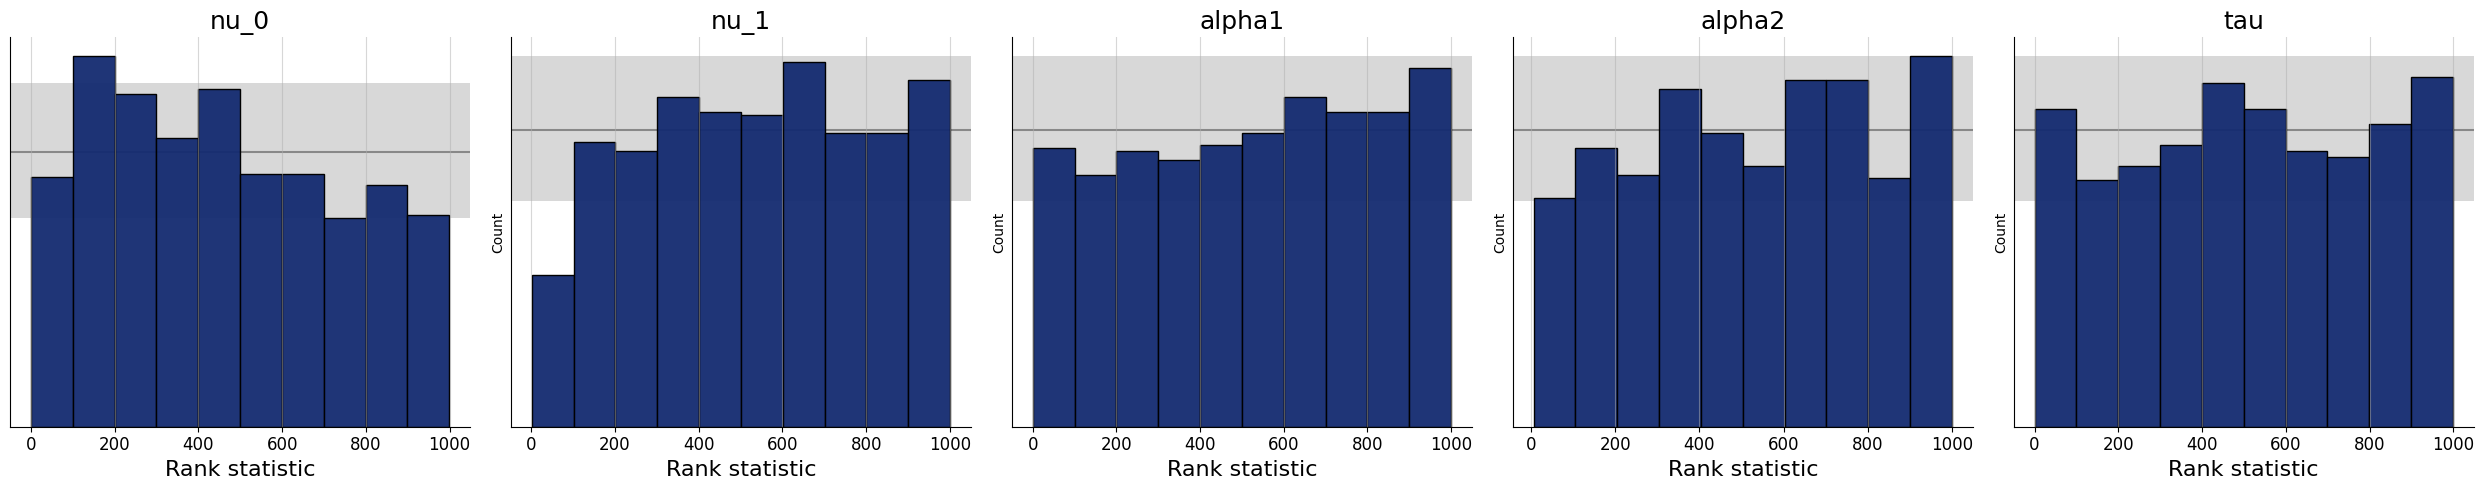

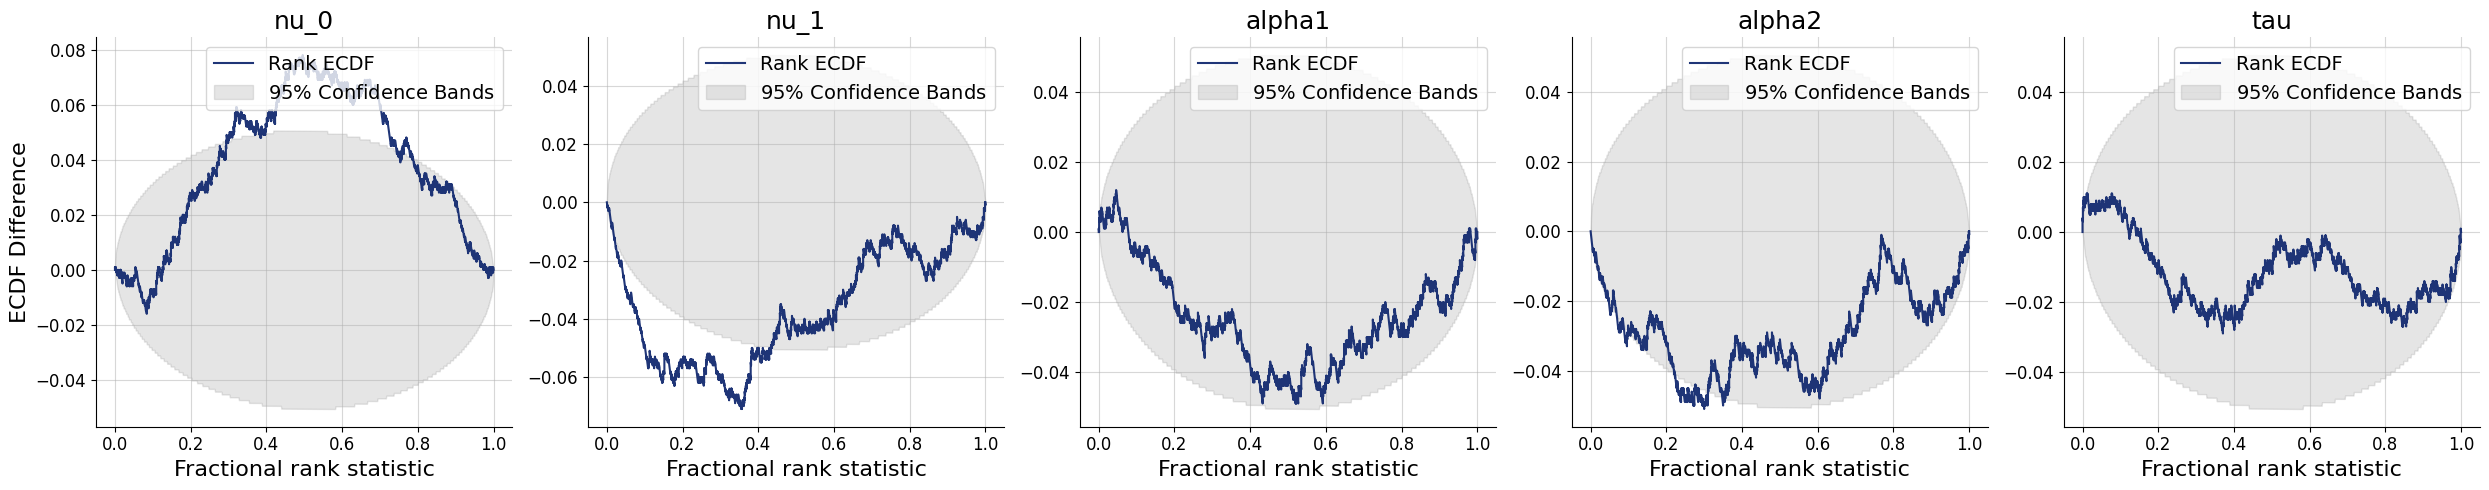

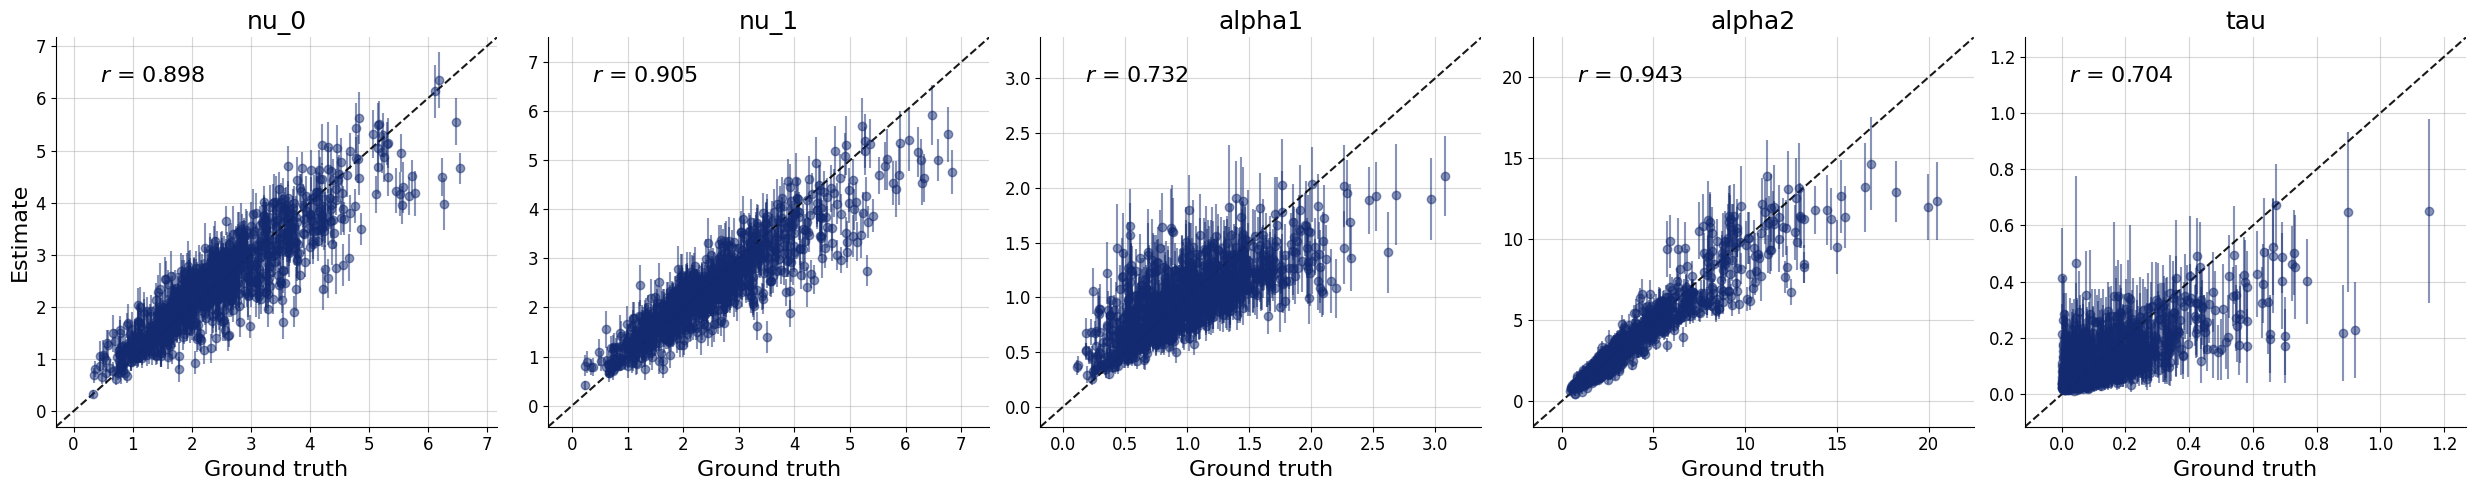

In [38]:

# ─── B) Draw posteriors on that test data ───────────────────────────────
posterior_sims_v2 = workflow.sample(
    num_samples = 1000,
    conditions  = test_sims_v2
)

# ─── C) Calibration histogram for each parameter ────────────────────────
f_hist_v2 = bf.diagnostics.plots.calibration_histogram(
    estimates = posterior_sims_v2,
    targets   = test_sims_v2
)

# ─── D) Calibration ECDF-difference plot ────────────────────────────────
f_ecdf_v2 = bf.diagnostics.plots.calibration_ecdf(
    estimates  = posterior_sims_v2,
    targets    = test_sims_v2,
    difference = True
)

# ─── E) Recovery scatterplots (true vs. inferred) ────────────────────────
f_recov_v2 = bf.diagnostics.plots.recovery(
    estimates = posterior_sims_v2,
    targets   = test_sims_v2
)

# Display the figures
for fig in (f_hist_v2, f_ecdf_v2, f_recov_v2):
    fig.show()
